In [1]:
import numpy as np
import pandas as pd

from statsmodels.tsa.api import ARIMA
from statsmodels.stats.api import het_arch, acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_predict

import pandas_datareader.data as web

# настройки визуализации
import matplotlib.pyplot as plt

# Не показывать Warnings
import warnings
warnings.simplefilter(action='ignore', category=Warning)
# Не показывать ValueWarning, ConvergenceWarning из statsmodels
from statsmodels.tools.sm_exceptions import ValueWarning, ConvergenceWarning
warnings.simplefilter('ignore', category=ValueWarning)
warnings.simplefilter('ignore', category=ConvergenceWarning)

In [2]:
y = web.DataReader(name='WGS10YR', data_source='fred', start='2000-01-01', end='2023-12-31')
y

,WGS10YR
DATE,
2000-01-07,6.56
2000-01-14,6.66
2000-01-21,6.77
2000-01-28,6.68
2000-02-04,6.58
...,...
2023-12-01,4.32
2023-12-08,4.19
2023-12-15,4.06


In [3]:
# спецификация модели
mod = ARIMA(y, order=(2,1,1), trend='n', missing='drop')
# подгонка модели на данных
res = mod.fit()

In [5]:
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                WGS10YR   No. Observations:                 1252
Model:                 ARIMA(2, 1, 1)   Log Likelihood                1133.584
Date:                Wed, 25 Mar 2026   AIC                          -2259.168
Time:                        17:57:29   BIC                          -2238.641
Sample:                    01-07-2000   HQIC                         -2251.452
                         - 12-29-2023                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1122     20.694      0.005      0.996     -40.447      40.672
ar.L2          0.0274      4.711      0.006      0.995      -9.206       9.261
ma.L1          0.1154     20.693      0.006      0.996     -40.442      40.673
sigma2         0.0096      0.000     31.747      0.000       0.009       0.010
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                87.81
Prob(Q):                              0.95   Prob(JB):                         0.00
Heteroskedasticity (H):               0.88   Skew:                             0.01
Prob(H) (two-sided):                  0.20   Kurtosis:                         4.30
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

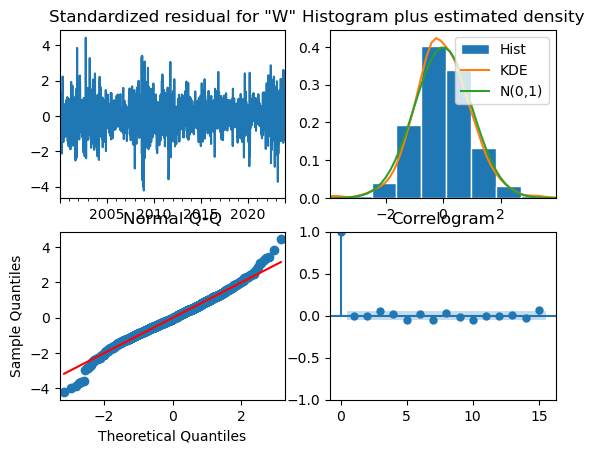

In [4]:
res.plot_diagnostics(lags=15)

plt.show()

Тест на серийную корреляцию (Ljung-Box test). Выберем число лагов 7

In [6]:
# корректировка степеней свободы: число оцениваемых коэффициентов = число параметров - 1 (-sigma2)
model_df = mod.k_params-1
# для тест отбрасываем первые d остатков (d=mod.k_diff)
acorr_ljungbox(res.resid[mod.k_diff:] , lags=[7], model_df=model_df)

,lb_stat,lb_pvalue
7,11.410513,0.022318


p-value > 0.01. Гипотеза не отвергается. Нет серийной корреляции

Тест на гетероскедастичность (на ARCH-эффекты)

In [8]:
# корректировка степеней свободы: число оцениваемых коэффициентов = число параметров - 1 (-sigma2)
model_df = mod.k_params-1
# для тест отбрасываем первые d остатков (d=mod.k_diff)
lm_stat, lm_pval, f_stat, f_pval = het_arch(res.resid[mod.k_diff:], nlags=7, ddof=model_df)

lm_stat, lm_pval

(np.float64(134.9232481552961), np.float64(5.874964526425982e-26))

p-value < 0.01. Нулевая гипотеза отвергается. Есть гетероскедастичность

# Модели типа ARCH

In [9]:
from sktime.forecasting.arch import ARCH
from sktime.utils.plotting import plot_series
# временной горизонт для прогнозирования
from sktime.forecasting.base import ForecastingHorizon

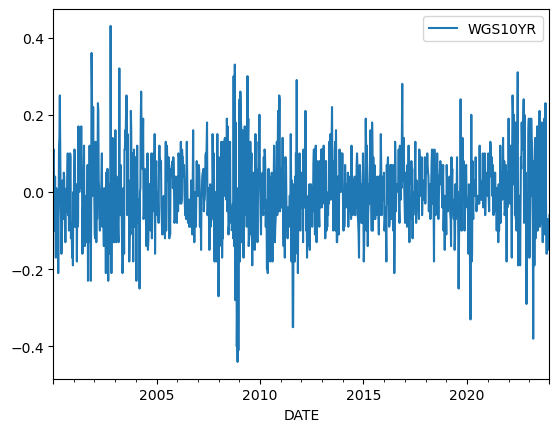

In [10]:
rate = web.DataReader(name='WGS10YR', data_source='fred', start='2000-01-01', end='2023-12-31')
y = rate.diff().dropna()

y.plot()
plt.show()

In [11]:
forecaster = ARCH(mean='AR', lags=1, vol='GARCH', p=1, q=1, power=2)  
forecaster.fit(y)

forecaster.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           AR - GARCH Model Results                           
==============================================================================
Dep. Variable:                   None   R-squared:                       0.051
Mean Model:                        AR   Adj. R-squared:                  0.050
Vol Model:                      GARCH   Log-Likelihood:                1208.29
Distribution:                  Normal   AIC:                          -2406.57
Method:            Maximum Likelihood   BIC:                          -2380.92
                                        No. Observations:                 1250
Date:                Wed, Mar 25 2026   Df Residuals:                     1248
Time:                        18:42:54   Df Model:                            2
                                  Mean Model                                  
==============================================================================
                  coef    std err          t      P>|t|       95.0% Conf. Int.
------------------------------------------------------------------------------
Const      -6.9868e-05  2.447e-03 -2.855e-02      0.977 [-4.866e-03,4.726e-03]
None[1]         0.2460  2.804e-02      8.774  1.725e-18      [  0.191,  0.301]
                              Volatility Model                              
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega      1.9890e-04  9.278e-05      2.144  3.205e-02 [1.705e-05,3.807e-04]
alpha[1]       0.0815  1.847e-02      4.412  1.024e-05   [4.529e-02,  0.118]
beta[1]        0.8989  2.407e-02     37.346 2.970e-305     [  0.852,  0.946]
============================================================================

Covariance estimator: robust
"""

In [12]:
forecaster.get_fitted_params()

{'Const': np.float64(-6.986771401695126e-05),
 'None[1]': np.float64(0.24601705289219278),
 'omega': np.float64(0.0001988999194306437),
 'alpha[1]': np.float64(0.08149866288099276),
 'beta[1]': np.float64(0.8988771483134504)}

In [13]:
# зададим горизонт прогнозирования и частотность
fh = ForecastingHorizon(np.arange(1,6), freq ='W-Fri')

y_pred = forecaster.fit_predict(y=y, fh=fh)

y_pred

,WGS10YR
2024-01-05,-0.014831
2024-01-12,-0.003719
2024-01-19,-0.000985
2024-01-26,-0.000312
2024-02-02,-0.000147
